In [74]:
from transformers import AutoTokenizer;
import numpy as np;
from matplotlib import pyplot as plt;
import matplotlib as mp

In [3]:
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2");

In [43]:
print(gpt2_tokenizer.get_vocab()["Action"])
print(gpt2_tokenizer.vocab_size);

print(gpt2_tokenizer.decode(12502))



12502
50257
Action


In [98]:
word = "👧"

print(len(word.encode("utf-8")))

x = [1,2,3]
y = [4, 5, 6]

for i, j in zip(x, y):
    print(f"i = {i} j = {j}")
    # print(i)


4
i = 1 j = 4
i = 2 j = 5
i = 3 j = 6


In [ ]:
lenOfChars = np.zeros(gpt2_tokenizer.vocab_size, dtype=np.int32);
lenOfBytes = np.zeros(gpt2_tokenizer.vocab_size, dtype=np.int32);

# i = 0;
# token_count = np.zeros((258, 258), dtype=np.int32);
# for vocobWord in gpt2_tokenizer.get_vocab():
#     lenOfChars[i] = len(vocobWord);
#     lenOfBytes[i] = len(vocobWord.encode("utf-8"));
#     token_count[lenOfChars[i], lenOfBytes[i]] += 1;
#     i += 1;

token_count = np.zeros((200, 200), dtype=np.int32);
for i in range(gpt2_tokenizer.vocab_size):
    tokenChar = gpt2_tokenizer.decode(i);
    
    lenOfChars[i] = len(tokenChar);
    lenOfBytes[i] = len(tokenChar.encode('utf-8'));
    
    token_count[lenOfChars[i], lenOfBytes[i]] += 1;

# print(lenOfChars);
# print(lenOfBytes);

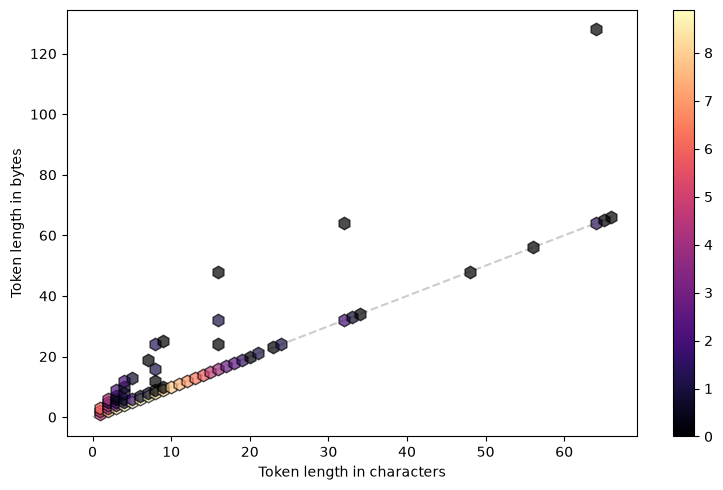

In [135]:
fig = plt.figure(figsize=(8,5));
norm = mp.colors.Normalize(vmin=0, vmax=np.log(token_count.max()))

x,y = np.nonzero(token_count)
for xi,yi in zip(x,y):
  plt.plot(xi,yi,'kh',alpha=.7,markersize=9, markerfacecolor=plt.cm.magma(norm(np.log(token_count[xi, yi]))))

sm = mp.cm.ScalarMappable(cmap=mp.cm.magma,norm=norm)
cbar = plt.colorbar(sm, ax = fig.gca())

plt.plot([0,xi],[0,xi],'--',color=[.8,.8,.8],zorder=-100)
plt.gca().set(xlabel='Token length in characters',
              ylabel='Token length in bytes');

# plt.xlim(-5, 70);
# plt.ylim(-5, 135);
plt.tight_layout();
plt.show();

In [161]:
# byteMax = lenOfBytes.max();
# byteMaxIndex = lenOfBytes.argmax();
# charAtIndex = lenOfChars[byteMaxIndex];


# print(f"byteMax = {byteMax}, byteMaxIndex = {byteMaxIndex}, char = {charAtIndex}");


greaterCharLen = np.where(lenOfChars < lenOfBytes)[0];
print(f'There are {len(greaterCharLen)} tokens with unequal lengths.\nHere are 30:\n');
for idx in greaterCharLen[np.random.randint(0,len(greaterCharLen),30)]:
    print(f'{gpt2_tokenizer.decode([idx])} | ',end='');

There are 873 tokens with unequal lengths.
Here are 30:

� | ы |  ● | σ | ω | 作 | ÃÂ | る | を | .� | �� | ْ | � | �� | � | ör | イ | oğ | � |  τ | � |  (£ | ス | � | � | � | ゼ | フォ | � | ― | 